### Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
xls = pd.ExcelFile("EastWestAirlines.xlsx")
xls.sheet_names


['Description', 'data']

#### 1.Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary

In [3]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name = "data")

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
# Preprocessing
# missing values

df.isna().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [8]:
# duplicate
df.duplicated().sum()

np.int64(0)

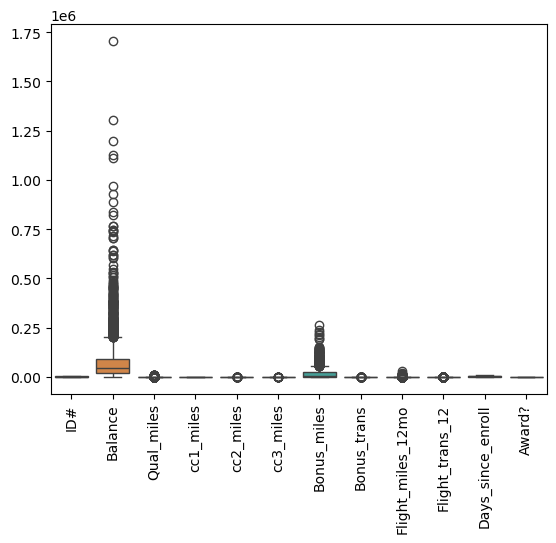

In [9]:
# outliers
sns.boxplot(data = df)
plt.xticks(rotation=90)
plt.show()

In [10]:
# handle outliers:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


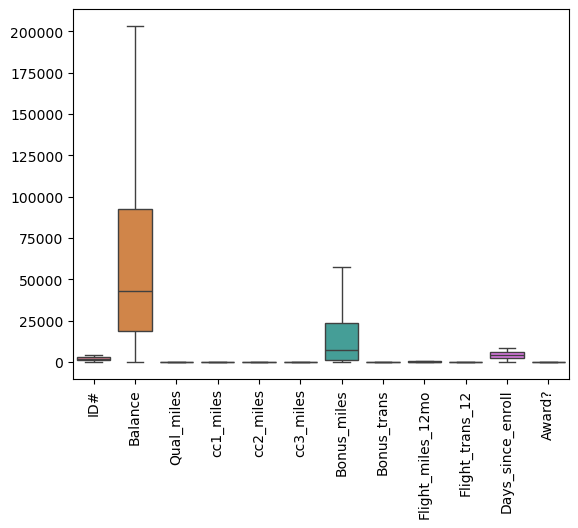

In [11]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

#### 2.Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

In [12]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns:", constant_columns)

Constant columns: ['Qual_miles', 'cc2_miles', 'cc3_miles']


In [13]:
corr = df.corr()
corr

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,1.000000,-0.269374,NaN,-0.224465,NaN,NaN,-0.210868,-0.156118,-0.083917,-0.082887,-0.964988,-0.177901
Balance,-0.269374,1.000000,NaN,0.446510,NaN,NaN,0.494422,0.409017,0.297045,0.295565,0.286143,0.170678
Qual_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc1_miles,-0.224465,0.446510,NaN,1.000000,NaN,NaN,0.912531,0.627786,0.098786,0.087618,0.230849,0.335457
cc2_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc3_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bonus_miles,-0.210868,0.494422,NaN,0.912531,NaN,NaN,1.000000,0.663558,0.205801,0.193669,0.217320,0.394061
Bonus_trans,-0.156118,0.409017,NaN,0.627786,NaN,NaN,0.663558,1.000000,0.310543,0.308518,0.170308,0.337444
Flight_miles_12mo,-0.083917,0.297045,NaN,0.098786,NaN,NaN,0.205801,0.310543,1.000000,0.942734,0.095019,0.293119
Flight_trans_12,-0.082887,0.295565,NaN,0.087618,NaN,NaN,0.193669,0.308518,0.942734,1.000000,0.091898,0.300085


In [14]:
corr=df[['ID#',
 'Balance',
 'cc1_miles',
 'Bonus_miles',
 'Bonus_trans',
 'Flight_miles_12mo',
 'Flight_trans_12',
 'Days_since_enroll',
 'Award?']].corr()
corr

,ID#,Balance,cc1_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,1.000000,-0.269374,-0.224465,-0.210868,-0.156118,-0.083917,-0.082887,-0.964988,-0.177901
Balance,-0.269374,1.000000,0.446510,0.494422,0.409017,0.297045,0.295565,0.286143,0.170678
cc1_miles,-0.224465,0.446510,1.000000,0.912531,0.627786,0.098786,0.087618,0.230849,0.335457
Bonus_miles,-0.210868,0.494422,0.912531,1.000000,0.663558,0.205801,0.193669,0.217320,0.394061
Bonus_trans,-0.156118,0.409017,0.627786,0.663558,1.000000,0.310543,0.308518,0.170308,0.337444
Flight_miles_12mo,-0.083917,0.297045,0.098786,0.205801,0.310543,1.000000,0.942734,0.095019,0.293119
Flight_trans_12,-0.082887,0.295565,0.087618,0.193669,0.308518,0.942734,1.000000,0.091898,0.300085
Days_since_enroll,-0.964988,0.286143,0.230849,0.217320,0.170308,0.095019,0.091898,1.000000,0.188121
Award?,-0.177901,0.170678,0.335457,0.394061,0.337444,0.293119,0.300085,0.188121,1.000000


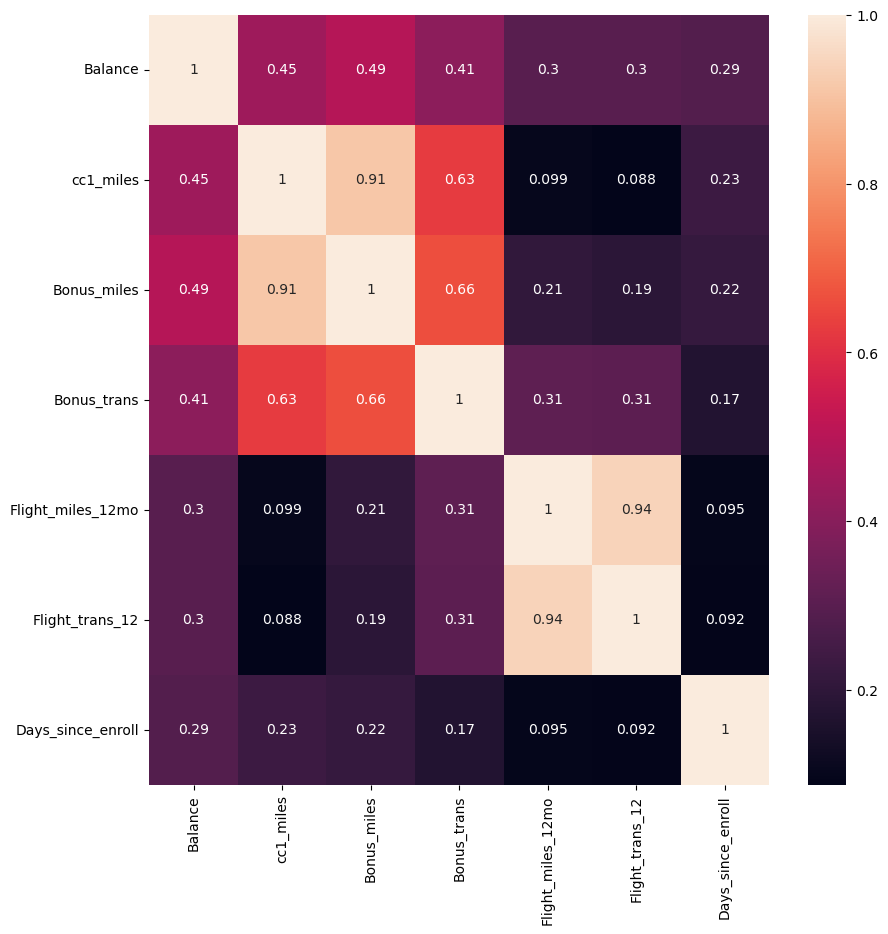

In [15]:
cols = ['Balance','cc1_miles','Bonus_miles','Bonus_trans',
        'Flight_miles_12mo','Flight_trans_12','Days_since_enroll']
corr = df[cols].corr()
plt.figure(figsize=(10,10))
ax=sns.heatmap(corr, annot=True)
plt.show()

#### 3.Use multiple visualizations to understand the hidden patterns in the dataset


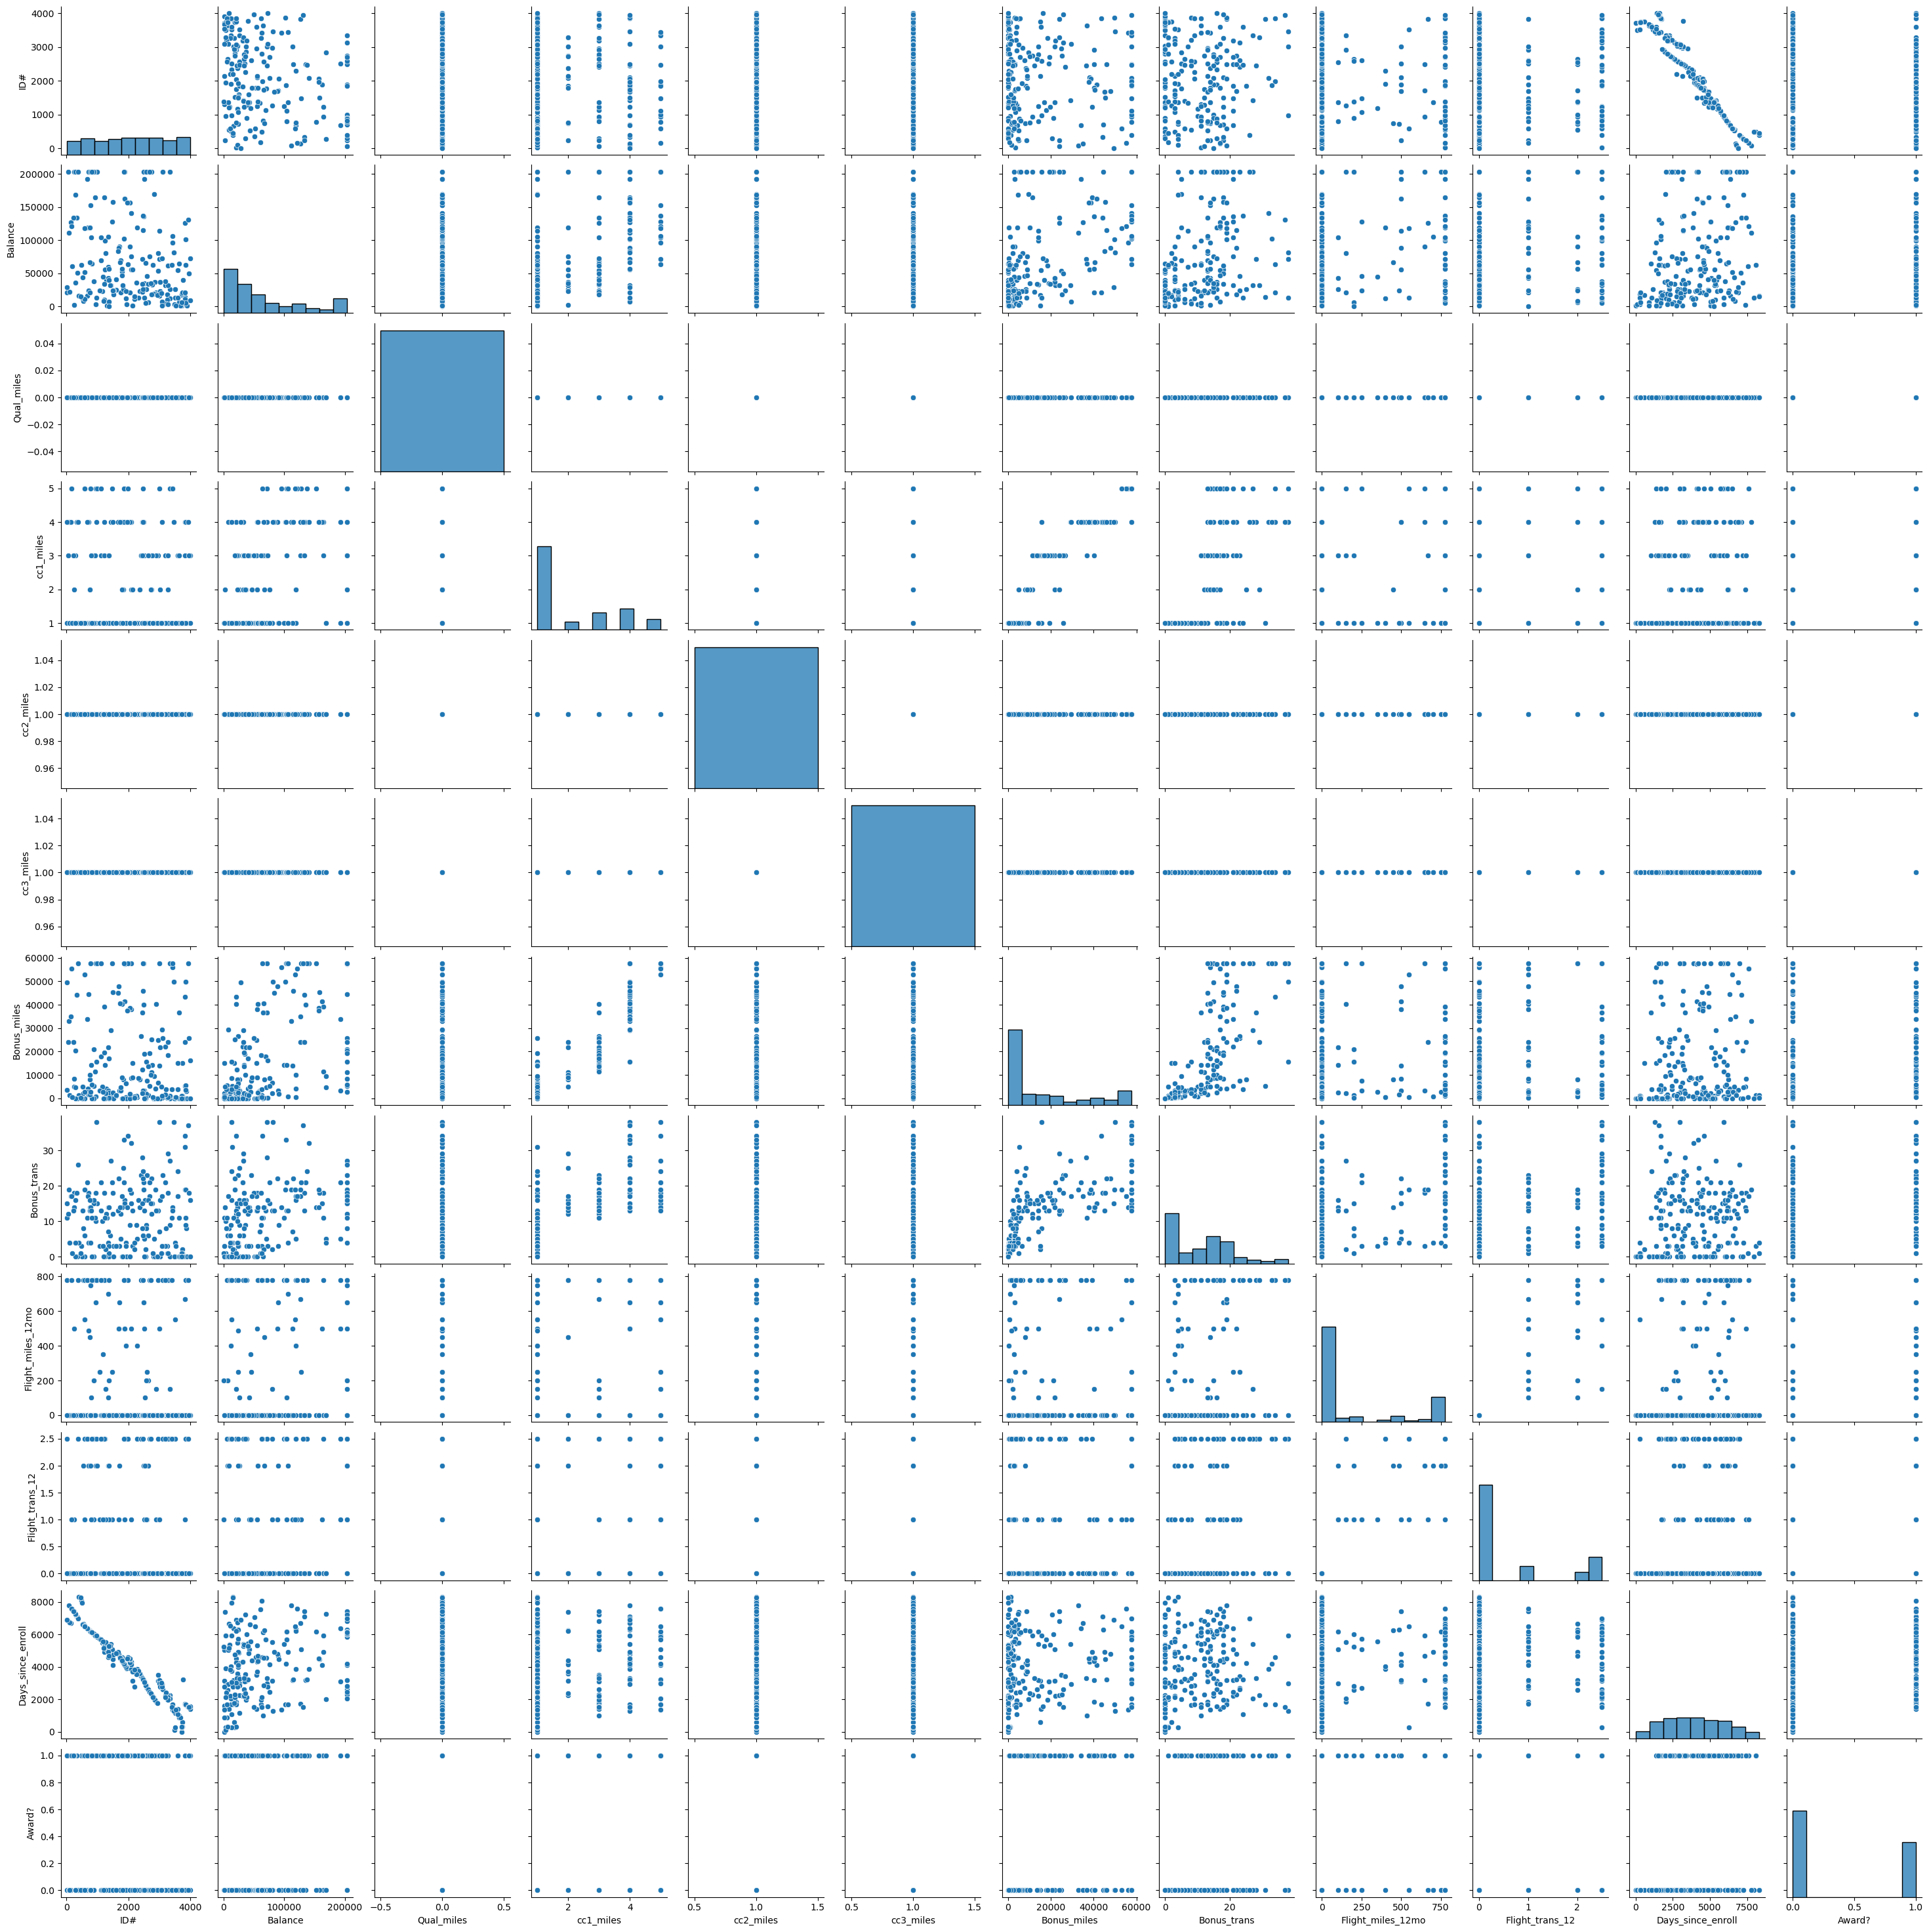

In [16]:
# pairplot
sns.pairplot(df.sample(200))
plt.show()

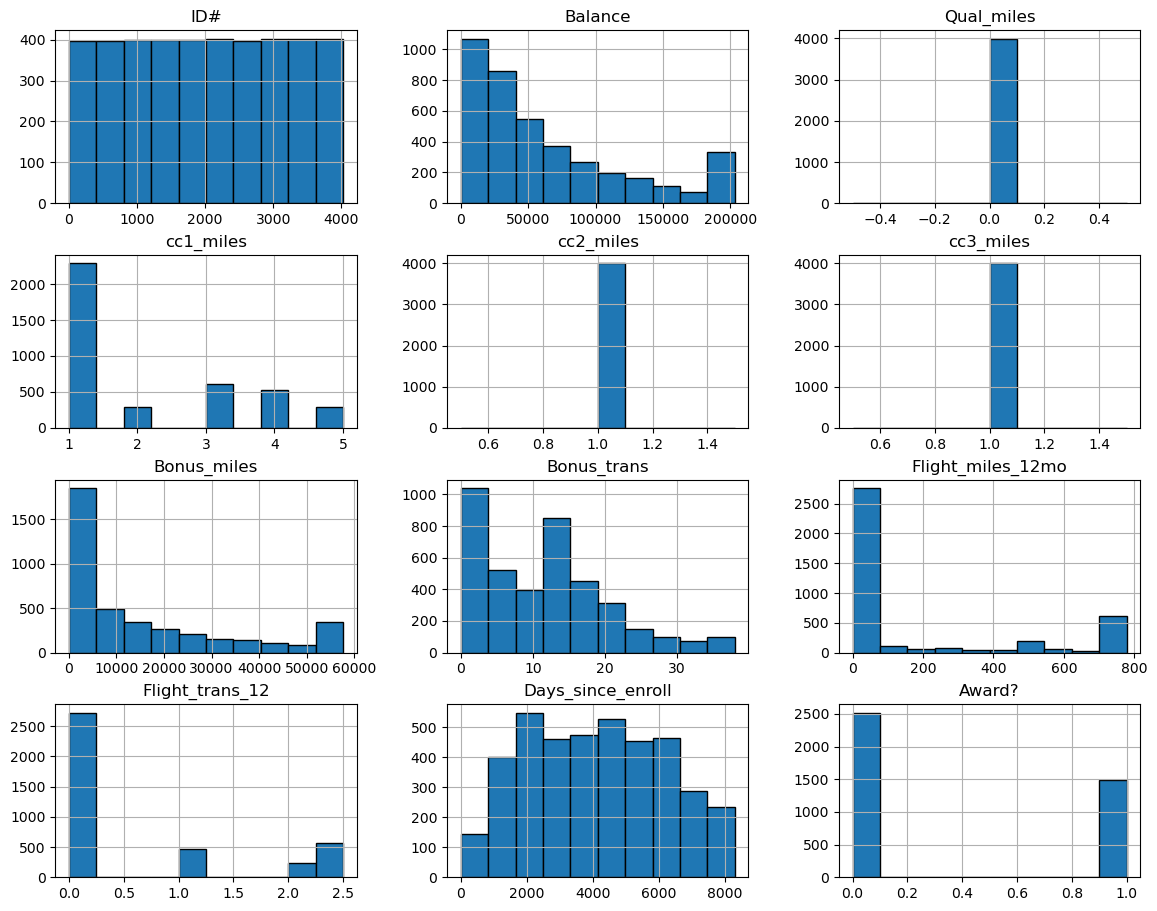

In [17]:
#histogram
df.hist(figsize=(14,11),edgecolor = 'black')
plt.show()


## Implementing Clustering Algorithms:

#### Implement the K-Means, hierarchical, and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.


In [18]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaled_df = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_df, columns=df.columns)


In [19]:
# Hierarchial Clustering:
df.columns.tolist()

['ID#',
 'Balance',
 'Qual_miles',
 'cc1_miles',
 'cc2_miles',
 'cc3_miles',
 'Bonus_miles',
 'Bonus_trans',
 'Flight_miles_12mo',
 'Flight_trans_12',
 'Days_since_enroll',
 'Award?']

In [20]:
features = df.drop(columns = ['ID#','Award?'])

In [21]:
features.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143.0,0,1,1,1,174.0,1,0.0,0.0,7000
1,19244.0,0,1,1,1,215.0,2,0.0,0.0,6968
2,41354.0,0,1,1,1,4123.0,4,0.0,0.0,7034
3,14776.0,0,1,1,1,500.0,1,0.0,0.0,6952
4,97752.0,0,4,1,1,43300.0,26,777.5,2.5,6935


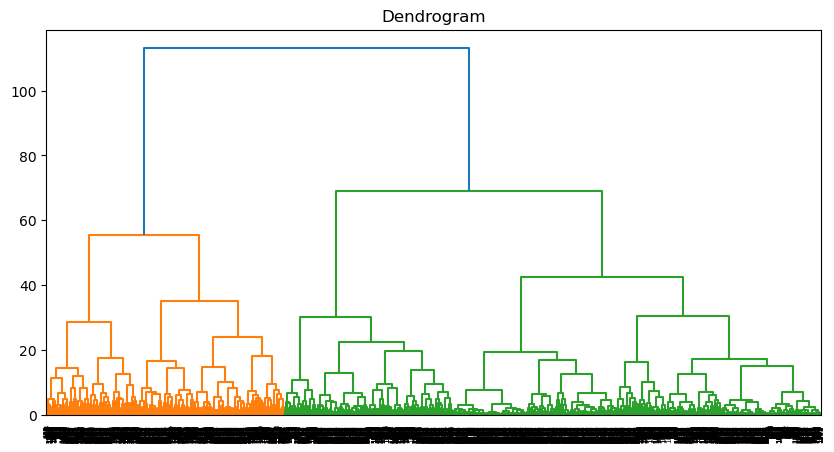

In [22]:
# visualizing dendogram
plt.figure(figsize=(10, 5))
Z = linkage(scaled_df, method='ward')
dendrogram(Z)
plt.title("Dendrogram")
plt.show()


In [23]:
agg = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')
labels_agg = agg.fit_predict(scaled_df)
df['Cluster_Agg'] = labels_agg
df['Cluster_Agg']

0       1
1       1
2       1
3       1
4       0
       ..
3994    0
3995    1
3996    2
3997    0
3998    1
Name: Cluster_Agg, Length: 3999, dtype: int64

In [24]:
df['Cluster_Agg'].value_counts()

Cluster_Agg
1    1902
0    1232
2     865
Name: count, dtype: int64

In [25]:
# Kmeans Clustering - Elbow Curve Method
inertia=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)
print(inertia)

[15087056099222.238, 4473200471352.039, 2437674119525.319, 1719749904525.3513, 1560572431363.5442, 1169066362754.3271, 1026819520189.2589, 867301194587.3921, 727107765401.5955, 624555239598.2747]


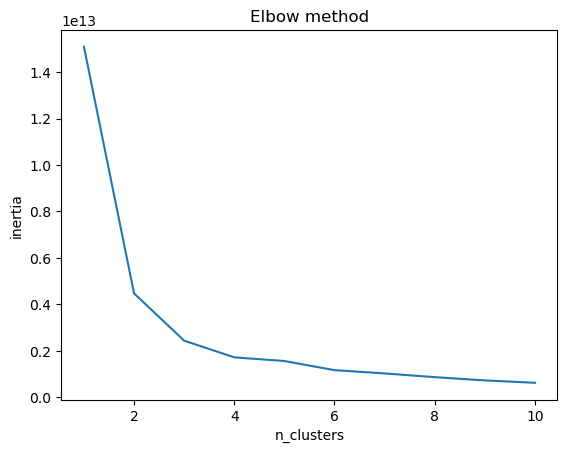

In [26]:
plt.plot(range(1,11),inertia)
plt.xlabel("n_clusters")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

In [27]:
k_means = KMeans(n_clusters=3, random_state=42)
labels_kmeans = k_means.fit_predict(scaled_df)
df['Cluster_KMeans'] = labels_kmeans
df['Cluster_KMeans']

0       0
1       0
2       0
3       0
4       2
       ..
3994    0
3995    0
3996    1
3997    0
3998    0
Name: Cluster_KMeans, Length: 3999, dtype: int32

In [28]:
df['Cluster_KMeans'].value_counts()

Cluster_KMeans
0    2111
1     996
2     892
Name: count, dtype: int64

In [29]:
# DBSCAN
# right value for eps,min_sample
eps=np.arange(0.5,5.5,0.5)
min_samples=range(2,15)

In [36]:
output=[]
for i in eps:
    for j in min_samples:
        labels=DBSCAN(eps=i,min_samples=j).fit(scaled_df).labels_
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            score = silhouette_score(scaled_df[mask], labels[mask])
        else:
            score = -1      
        output.append([i, j, score])
a = pd.DataFrame(output, columns=['eps','min_samples','score'])

In [31]:
best = a.loc[a['score'] == a['score'].max()]
print("Best parameters:")
print(best)


Best parameters:
    eps  min_samples     score
17  1.0            6  0.152591


In [32]:
labels=DBSCAN(eps=1.0,min_samples=6).fit(scaled_df).labels_

In [37]:
from collections import Counter
print(Counter(labels))

Counter({np.int64(0): 3999})


In [38]:
np.unique(labels)

array([0])

# Cluster Analysis and Interpretation:


##### in agglomerative clustering cluster 1 is the largest as it contains 1902 data points which is majority. cluster 2 represent outliers in kmeans clustering cluster 0 is dominant , most data points are around this centroid cluster 1 and cluster 2 are smaller in DBSCAN clustering we have a different clusters varying its size , even a small cluster with 7 points . 152 points are considered noise . silhouette score is 0.15 is low which means they are not perfectly separated

# Visualization:

In [39]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [40]:
agg_labels = labels_agg
kmeans_labels = labels_kmeans
dbscan_labels = labels 

In [41]:
pca = PCA(n_components=2)
data_2d = pca.fit_transform(scaled_df)

In [42]:
def plot_clusters(data, labels, title):
    plt.figure(figsize=(8,6))
    palette = sns.color_palette('tab10', n_colors=len(set(labels)))
    sns.scatterplot(x=data[:,0], y=data[:,1], hue=labels, palette=palette, s=50, legend='full')
    plt.title(title)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.show()

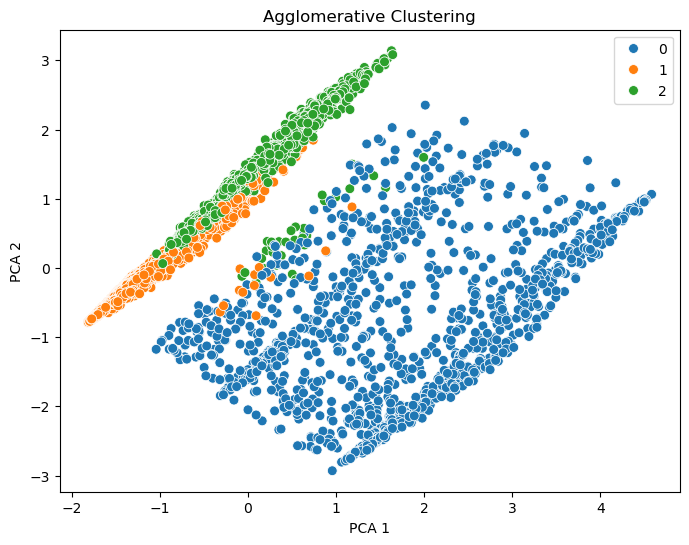

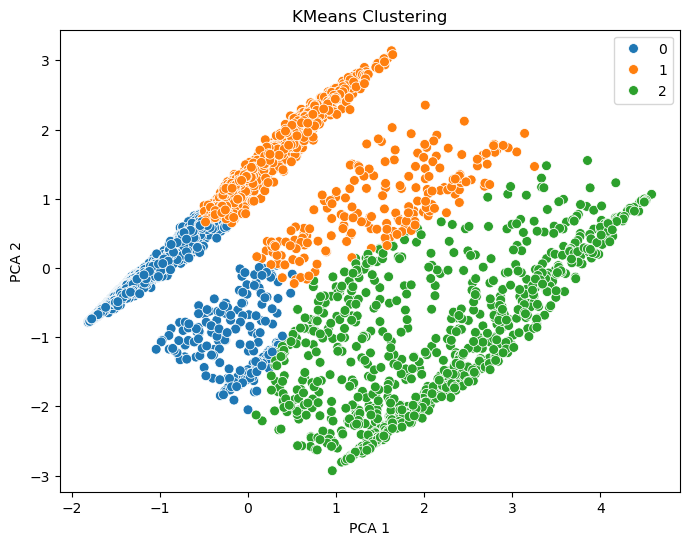

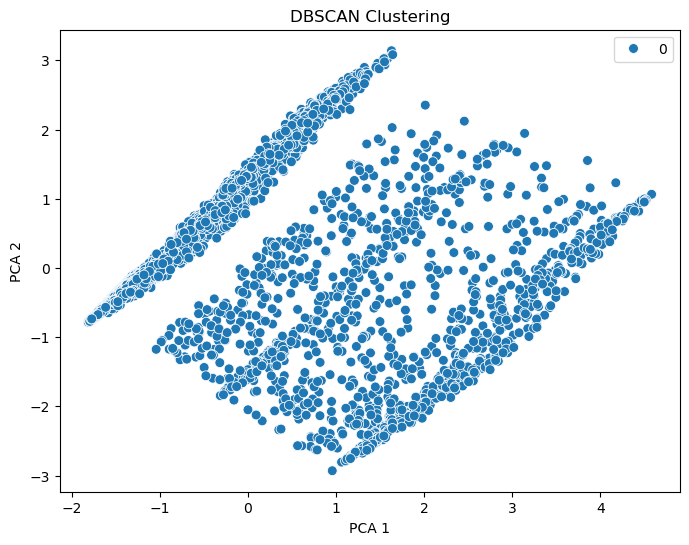

In [43]:
# Agglomerative
plot_clusters(data_2d, agg_labels, 'Agglomerative Clustering')
# KMeans
plot_clusters(data_2d, kmeans_labels, 'KMeans Clustering')
# DBSCAN
plot_clusters(data_2d, dbscan_labels, 'DBSCAN Clustering')

In [44]:
# Evaluation and Performance Metrics:

In [45]:
silhouette_score(scaled_df,kmeans_labels)

np.float64(0.3289528188683356)

In [47]:
# clusters are more compact and well separated

In [48]:
silhouette_score(scaled_df,agg_labels)

np.float64(0.25930930847212086)

In [49]:
# clusters are less distinct so some points dont fit perfectly

In [50]:
import numpy as np
mask =labels != -1
if len(set(labels[mask])) > 1:
    sil_dbscan = silhouette_score(scaled_df[mask],labels[mask])
    print(f"DBSCAN Silhouette Score: {sil_dbscan:.3f}")
else:
    print("DBSCAN: Not enough clusters to compute silhouette score")

DBSCAN: Not enough clusters to compute silhouette score


##### low score compared to others , have irregular shapes and some points are noise